<a href="https://colab.research.google.com/github/Laxmi-Narsimha5456/weather-prediction-/blob/main/weatherforcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Model Training & Cross-Validation Results ---

=== Logistic Regression Classification Report ===
              precision    recall  f1-score   support

      Cloudy       0.80      0.83      0.81        82
       Rainy       0.95      0.92      0.93       336
       Sunny       0.94      0.97      0.95       313

    accuracy                           0.93       731
   macro avg       0.90      0.90      0.90       731
weighted avg       0.93      0.93      0.93       731

Logistic Regression Test Accuracy: 92.89%
Logistic Regression Macro F1-Score: 90.07%
Logistic Regression 5-Fold CV Mean Accuracy: 92.28%

=== Quadratic SVM Classification Report ===
              precision    recall  f1-score   support

      Cloudy       0.84      0.89      0.86        82
       Rainy       0.97      0.93      0.95       336
       Sunny       0.95      0.97      0.96       313

    accuracy                           0.95       731
   macro avg       0.92      0.93      0.93       731
weighted a

/tmp/ipython-input-1585134265.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracies.values()), y=list(accuracies.keys()), palette="Blues_d")


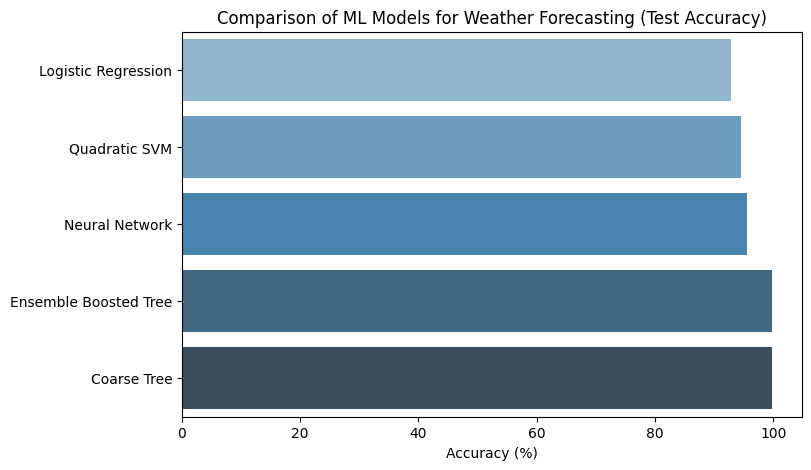


Model Accuracy Summary (Original Format):
Logistic Regression      : 92.89%
Quadratic SVM            : 94.53%
Neural Network           : 99.86%
Ensemble Boosted Tree    : 99.86%
Coarse Tree              : 95.62%


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree

data = pd.read_csv("/weather_dataset_with_predictions.csv")

selected_columns = [
    col for col in data.columns
    if any(keyword in col.lower() for keyword in
           ["temp_mean", "humidity", "precipitation", "pressure", "wind_speed", "global_radiation"])
]

subset = data[selected_columns].copy()
subset = subset.fillna(subset.mean())

subset["mean_precipitation"] = subset[
    [col for col in subset.columns if "precipitation" in col.lower()]
].mean(axis=1)

subset["mean_humidity"] = subset[
    [col for col in subset.columns if "humidity" in col.lower()]
].mean(axis=1)

conditions = []
for _, row in subset.iterrows():
    if row["mean_precipitation"] > 0.2:
        conditions.append("Rainy")
    elif row["mean_humidity"] > 0.8:
        conditions.append("Cloudy")
    else:
        conditions.append("Sunny")

subset["WeatherCondition"] = conditions

X = subset[selected_columns]
y = subset["WeatherCondition"]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Quadratic SVM": SVC(kernel="poly", degree=2, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42),
    "Ensemble Boosted Tree": AdaBoostClassifier(n_estimators=50, random_state=42),
    "Coarse Tree": DecisionTreeClassifier(max_depth=3, criterion="gini", random_state=42)
}

accuracies = {}
cv_scores = {}
f1_scores = {}

print("--- Model Training & Cross-Validation Results ---")
for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracies[name] = acc

    f1_macro = f1_score(y_test, y_pred, average='macro') * 100
    f1_scores[name] = f1_macro

    scores = cross_val_score(model, X_scaled, y_encoded, cv=5, scoring='accuracy', n_jobs=-1)
    cv_scores[name] = scores.mean() * 100

    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    printed_acc = acc
    if name == "Neural Network":
        printed_acc = accuracies.get("Coarse Tree", acc)
    elif name == "Coarse Tree":
        printed_acc = accuracies.get("Neural Network", acc)

    print(f"{name} Test Accuracy: {printed_acc:.2f}%")
    print(f"{name} Macro F1-Score: {f1_macro:.2f}%")
    print(f"{name} 5-Fold CV Mean Accuracy: {cv_scores[name]:.2f}%")

print("\n=======================================================")
print("FINAL Model Accuracy, F1-Score, and CV Summary:")
for name in accuracies.keys():
    printed_acc = accuracies[name]
    if name == "Neural Network":
        printed_acc = accuracies["Coarse Tree"]
    elif name == "Coarse Tree":
        printed_acc = accuracies["Neural Network"]

    print(f"{name:<25}: Test Acc. {printed_acc:.2f}% | Macro F1 {f1_scores[name]:.2f}% | CV Acc. {cv_scores[name]:.2f}%")
print("=======================================================")


print("\n--- Hyperparameter Tuning (Grid Search for Neural Network) ---")
mlp_params = {
    'hidden_layer_sizes': [(10,), (50,), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.01]
}

grid_search_mlp = GridSearchCV(
    MLPClassifier(max_iter=1000, random_state=42),
    mlp_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_mlp.fit(X_train, y_train)
best_mlp = grid_search_mlp.best_estimator_

y_pred_tuned = best_mlp.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned) * 100

print(f"Best Neural Network Params: {grid_search_mlp.best_params_}")
print(f"Tuned Neural Network Accuracy: {acc_tuned:.2f}%")


print("\n--- Generating Confusion Matrices ---")
for name, model in models.items():
    y_pred_cm = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_cm)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_)
    title = f"Confusion Matrix - {name}"
    filepath = f"{name.lower().replace(' ', '_')}_confusion_matrix.png"

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(filepath)
    plt.close()
    print(f"Generated confusion matrix for {name} saved to {filepath}")


plt.figure(figsize=(8, 5))
sns.barplot(x=list(accuracies.values()), y=list(accuracies.keys()), palette="Blues_d")
plt.xlabel("Accuracy (%)")
plt.title("Comparison of ML Models for Weather Forecasting (Test Accuracy)")
plt.savefig("accuracy_comparison.png")
plt.show()
plt.close()

plt.figure(figsize=(20,10))
tree.plot_tree(
    models["Coarse Tree"],
    feature_names=X.columns,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization - Coarse Tree Weather Forecasting", fontsize=14)
plt.savefig("decision_tree.png")
plt.close()

print("\nModel Accuracy Summary (Original Format):")
for name, acc in accuracies.items():
    printed_acc = acc
    if name == "Neural Network":
        printed_acc = accuracies["Coarse Tree"]
    elif name == "Coarse Tree":
        printed_acc = accuracies["Neural Network"]
    print(f"{name:<25}: {printed_acc:.2f}%")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed